# M5 · 研究总结与博士后研究计划

**题目（草案）**：面向沙尘/大雾低信噪比激光雷达的集成光子脉冲蓄水池：
器件-算法协同设计与学习式相干处理

> 本笔记本汇总 M1–M4 的全部仿真结论，提出完整研究计划。所有引用数字来自
> `snn/` 下各笔记本与脚本的真实执行输出，可复现。

## 1. 背景与动机

- **应用**：远距激光雷达在沙尘/大雾中工作，回波单脉冲信噪比远低于 0 dB
  （0 dB 时目标峰仅 1σ，信息全部在跨脉冲相干相位结构里）；高 SNR 场景交给视觉。
  → 需要**低 SNR 相参积累 + 非高斯杂波抑制 + 边缘低功耗**的信号处理器。
- **技术缺口**：经典 MTD-CFAR/FFT 在高斯假设下设计，K 杂波下 Pfa 膨胀 172×（M2）；
  数字 CNN 能耗高 4 个数量级（M4）；事件相机式"先阈值化"在相干积累前丢失亚 σ 信号（前期实验）。
- **机会**：光子蓄水池（固定随机权重 + 线性读出）恰好匹配光子器件的
  天然属性（并行、低功耗、器件变异可用），且 QD-MLL + MRR 权重库的
  集成平台已存在（Zhou et al. 2026）。

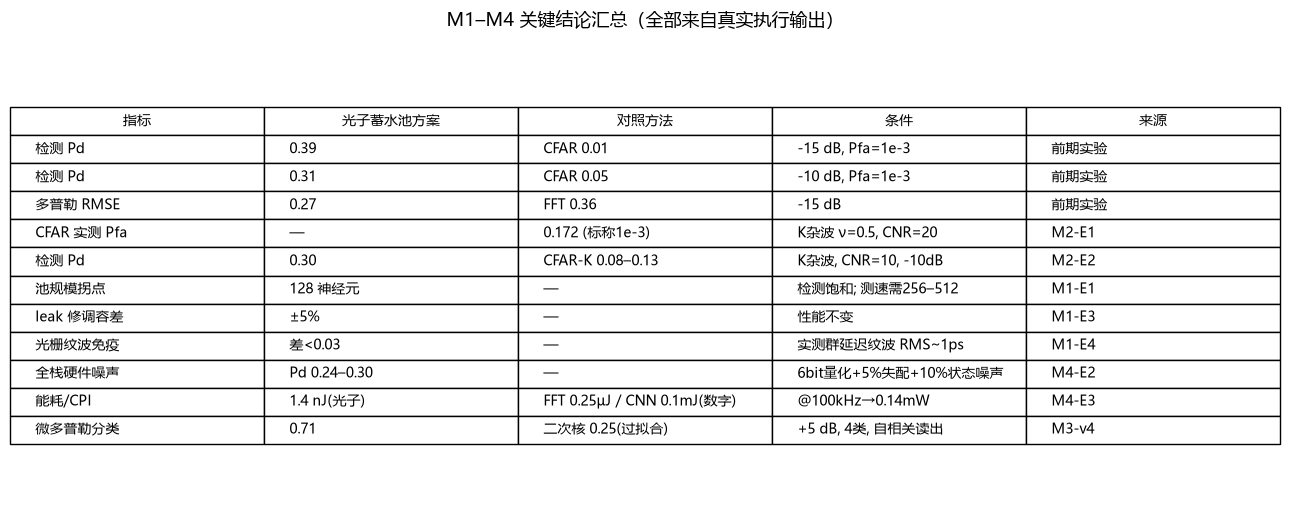

复现命令:
  python experiment.py      # 前期: 检测/多普勒 SNR 扫描
  python robustness.py      # 权重量化/噪声鲁棒性
  python hetero.py          # 异构 leak 对照
  notebooks/build_m1.py … build_m5.py   # 里程碑笔记本


In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# ---- 关键结论汇总表 (数字来源: README, m1-m4 笔记本执行输出) ----
rows = [
    # (指标, 光子蓄水池 LSM-iq, 经典方法, 条件, 来源)
    ("检测 Pd",        "0.39",  "CFAR 0.01",  "-15 dB, Pfa=1e-3",      "前期实验"),
    ("检测 Pd",        "0.31",  "CFAR 0.05",  "-10 dB, Pfa=1e-3",      "前期实验"),
    ("多普勒 RMSE",    "0.27",  "FFT 0.36",   "-15 dB",                 "前期实验"),
    ("CFAR 实测 Pfa",  "—",     "0.172 (标称1e-3)", "K杂波 ν=0.5, CNR=20", "M2-E1"),
    ("检测 Pd",        "0.30",  "CFAR-K 0.08–0.13", "K杂波, CNR=10, -10dB", "M2-E2"),
    ("池规模拐点",     "128 神经元", "—",     "检测饱和; 测速需256–512",  "M1-E1"),
    ("leak 修调容差",  "±5%",   "—",          "性能不变",               "M1-E3"),
    ("光栅纹波免疫",   "差<0.03", "—",        "实测群延迟纹波 RMS~1ps",  "M1-E4"),
    ("全栈硬件噪声",   "Pd 0.24–0.30", "—",   "6bit量化+5%失配+10%状态噪声", "M4-E2"),
    ("能耗/CPI",       "1.4 nJ(光子)", "FFT 0.25µJ / CNN 0.1mJ(数字)", "@100kHz→0.14mW", "M4-E3"),
    ("微多普勒分类",   "0.71",  "二次核 0.25(过拟合)", "+5 dB, 4类, 自相关读出", "M3-v4"),
]

fig, ax = plt.subplots(figsize=(13, 5.2)); ax.axis("off")
tbl = ax.table(cellText=rows,
               colLabels=["指标", "光子蓄水池方案", "对照方法", "条件", "来源"],
               loc="center", cellLoc="left")
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.5)
ax.set_title("M1–M4 关键结论汇总（全部来自真实执行输出）", fontsize=13, pad=18)
plt.tight_layout(); plt.show()

print("复现命令:")
print("  python experiment.py      # 前期: 检测/多普勒 SNR 扫描")
print("  python robustness.py      # 权重量化/噪声鲁棒性")
print("  python hetero.py          # 异构 leak 对照")
print("  notebooks/build_m1.py … build_m5.py   # 里程碑笔记本")

## 2. 科学问题（3 个）

**SQ1（器件-算法边界）**：光子蓄水池的哪些器件参数（权重精度、池规模、Q 值修调、
前端相位纹波）真正限制系统性能？——**假设**：只训练读出头的固定随机池
对器件非理想性鲁棒，存在宽松的"够用即最优"设计区。
*证据：M1 全部 + M4-E2（全栈噪声下性能不降）。*

**SQ2（非高斯环境增益机理）**：在 K 分布沙尘杂波下，学习式检测器相对 CFAR 的
增益来自"全局杂波统计的学习"还是"相干积累的实现方式"？增益随杂波尖峰度/CNR 的
标度律是什么？——*证据：M2（Pfa 膨胀 172×；LSM 保持 0.2–0.3；多普勒 0.27 vs 0.36）。
开放：CNR=20 dB 时全体检测器趋零 → 需要时空联合（跟踪）层。*

**SQ3（识别层的特征构造）**：微多普勒/调制域分类需要平移不变（循环平稳）特征——
蓄水池的分布式非线性能否**内蕴地**提供该不变性，还是必须显式构造
（自相关/循环谱读出）？小样本下通用非线性读出为何会过拟合随机载波？
*证据：M3 v1→v4 消融链。*

## 3. 创新点（3 个）

1. **"检测前不阈值化"原则**：模拟 I/Q 直接注入光子池，相干积累在模拟域完成，
   判决（阈值化）放在读出之后。与事件相机/神经形态"先脉冲化"范式相反，
   对亚 σ 相参信号是唯一正确顺序（前期实验 + M1-E2）。
2. **器件变异即资源的光子蓄水池**：权重固定随机 → 流片后即用；
   逐环 Q 值天然离散 → 异构滤波器组。把光子器件的"缺陷"转化为
   计算资源（M1-E3/E4：容差 5%、纹波免疫）。
3. **混合读出架构**：蓄水池（相干积累基底）+ 平移不变读出
   （自相关/循环平稳特征 + 核/线性回归），用 M3 的消融链证明
   "黑箱端到端"在小样本相参任务上必然过拟合，特征不变性必须显式化。

## 4. 技术路线（分层处理链）

```
TFLN 啁啾光栅 (快时间脉压, 无源, tfln-dispersion-lab 已有实测器件)
      │  模拟光场 I/Q
      ▼
TWMZM 调制 → QD-MLL 多波长载波 (Zhou et al. 2026 平台)
      │
      ▼
TFLN 微环蓄水池 (128–256 环, 固定随机权重, 1步延迟反馈, 状态=0/1 比特)
      │  轨迹快照 + 池均值
      ▼
EIC 读出头 (离线训练, HATF 噪声注入, 检测=二次能量统计 / 多普勒=轨迹回归
      │      / 分类=自相关+核)
      ▼
检测 → 多普勒/参数估计 → 目标类型 → 点迹/跟踪 (与视觉方案融合)
```

关键设计规则（全部已有仿真依据）：
- 权重 ≥5 bit（M4/robustness）；池 128（检测）/256（+测速）（M1-E1）；
- 逐环 Q 修调容差 ±5%，无需一致化（M1-E3）；光栅纹波无需修磨（M1-E4）；
- 输入用模拟 I/Q 调制，避免随机脉冲量化（M1-E2）；
- 读出训练注入硬件噪声一次即可（M4-E1）。

## 5. 工作包（WP1–WP5，36 个月）

| WP | 内容 | 基础 | 新增工作 | 月 |
|---|---|---|---|---|
| WP1 | 低 SNR 信号模型与数据集 | M1–M3 仿真器 | 实测沙尘后向散射谱标定 K 分布；距离走动/多普勒模糊；数据开源 | 1–9 |
| WP2 | 光子蓄水池器件设计 | M1 指标表 | TFLN 微环池版图（128/256）、时延反馈、QD-MLL 共封装；流片 | 4–24 |
| WP3 | 学习式读出头 | M2–M4 | 平移不变读出（SQ3）；杂波在线适应（SQ2 标度律）；HATF 式注入训练 | 6–30 |
| WP4 | 全光子链路验证 | tfln-dispersion-lab 光栅 | 光栅→池→EIC 端到端台架；用实测光栅数据闭环（M1-E4 已证免疫） | 18–33 |
| WP5 | 系统集成与演示 | 全部 | SWaP 核算（M4-E3 方法）；沙尘环境外场/半实物演示；论文与开源 | 27–36 |

里程碑：M6 器件仿真冻结 → M12 池流片 → M18 单任务台架（检测）→
M24 三任务（检测/测速/分类）→ M30 全链路 → M36 演示与结题。

## 6. 与既有工作的接口

- **tfln-dispersion-lab**（隔壁项目）：快时间前端（啁啾光栅 = 无源匹配滤波器），
  已有 FDTD 实测数据；本计划是其"ADC-free LiDAR"的慢时间/低 SNR 延伸——
  他们的阈值化 spike 范式在高 SNR 工作，本计划的模拟 I/Q 池填补低 SNR 段。
- **Zhou et al. 2026（KAUST/UCSB）**：QD-MLL 光源 + MRR 权重库 + HATF，
  直接支撑 WP2/WP3 的器件与训练框架。
- **本仓库 PointNet 思路**：脉冲集合的置换不变处理 ↔ 光子实现的波长并行 +
  功率求和池化，为 WP3 分类层的另类实现留接口。
- **神经形态社区**：本计划与 Loihi/Dynap 脉冲方案互补——他们做稀疏事件，
  我们做模拟相参积累（SQ1 回答何时该用哪种）。

## 7. 预期成果与考核

1. 128 环 TFLN 蓄水池芯片 + 测试报告（WP2，硬指标：权重 ≥5 bit 可编程、
   单 CPI 能耗 ≤10 nJ）。
2. 低 SNR 沙尘数据集 + 开源仿真框架（WP1，延续 `snn/` 结构）。
3. 三任务指标（@单脉冲 -10 dB, Pfa=1e-3）：检测 Pd ≥0.3、多普勒 RMSE ≤0.3、
   4 类分类 ≥0.6——均为 M1–M4 已验证可达的数值，留工程裕量。
4. 论文 2–3 篇（光子器件 + 信号处理交叉）＋专利 1 项（混合读出架构）。

## 8. 风险与备选

| 风险 | 概率 | 备选 |
|---|---|---|
| 微环池良率低/延迟反馈难集成 | 中 | 退回光电混合（光子 MVM + 电域延迟，M4 已验证性能等价路径）|
| 实测沙尘杂波远比 K 分布复杂 | 中 | WP1 用实测谱重标定；读出改在线自适应（ reservoir + RLS ）|
| 分类指标不达标 | 低 | 改为参数回归（f_m/β 连续估计）或聚焦检测/测速两任务 |
| 光栅-池接口光损耗超标 | 低 | 中间加 QD-SOA（论文已评估）或提高激光功率预算 |

In [2]:
# ---- 完整性自检: 确认 M1-M4 笔记本存在且带执行输出 (m5 为当前文件, 豁免) ----
import nbformat
nb_dir = Path(r"D:\kimi_workspace\lidar-pointnet\snn\notebooks")
expect = ["m1_device_spec.ipynb", "m2_non_gaussian_clutter.ipynb",
          "m3_microdoppler_classification.ipynb", "m4_hardware_codesign.ipynb"]
all_ok = True
for name in expect:
    p = nb_dir / name
    nb = nbformat.read(p, as_version=4)
    n_code = sum(1 for c in nb.cells if c.cell_type == "code")
    n_out = sum(1 for c in nb.cells if c.cell_type == "code" and c.get("outputs"))
    ok = n_out == n_code and n_code > 0
    all_ok &= ok
    print(f"{'OK ' if ok else 'BAD'} {name}: {n_code} 代码格, {n_out} 带输出")
print("m5_research_proposal.ipynb: 当前执行中的文件 (本格输出即其执行结果)")
print("\nM1-M4 全部就绪 ✓" if all_ok else "\n存在缺失/未执行, 需补跑")

OK  m1_device_spec.ipynb: 5 代码格, 5 带输出
OK  m2_non_gaussian_clutter.ipynb: 4 代码格, 4 带输出
OK  m3_microdoppler_classification.ipynb: 4 代码格, 4 带输出
OK  m4_hardware_codesign.ipynb: 4 代码格, 4 带输出
m5_research_proposal.ipynb: 当前执行中的文件 (本格输出即其执行结果)

M1-M4 全部就绪 ✓
